## Statistical comparison of AWS Arctic retrievals and EarthCARE

This notebook plots 1D histograms and 2D conditional distributions of **collocated** AWS FWP (or LWP) and EarthCARE IWP (or LWP).
The actual statistics are computed using ``compute_aws_earthcare_coloc_stats.py``, which loads the collocations, averages over EarthCARE data, and calculates the histograms.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import xarray as xr
import pickle
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import cmocean as cmc

sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import utils
import plot_utils

plt.style.use("../plotstyling.mplstyle")

In [3]:
date_str = "2025-07_to_2026-06"
quantity = "lwp"   # or "lwp"
months = utils.calendar_months(date_str)

variable_label = quantity.upper()


with open(f"../data/aws_earthcare_histograms_{date_str}.pkl", "rb") as f:
    h_all = pickle.load(f)
h = h_all[quantity]

total_aws_counts = h["aws_counts"]
total_ea_counts = h["ea_counts"]
total_aws_n = h["aws_n"]
total_ea_n = h["ea_n"]

bins = h["bins"]
bin_widths = np.diff(bins)
bin_centres = np.sqrt(bins[:-1] * bins[1:])
bin_centres[0] = 5e-5   # stand-in for the 0 to 1e-4 bin

In [4]:
# load simulation data and filter for same timeframe


ds_training = xr.open_dataset("/scratch/evoy/easy_arts_output/AWS/2026-03-08_arctic_run1/combined_2026-03-08_run0_run1_2026-02-05_2026-01-20_training.nc")

db_months = pd.DatetimeIndex(ds_training.CloudSat_Datetime.values).month
keep = np.isin(db_months, months)

values = ds_training[quantity.capitalize()].values[keep]
print(f"{keep.sum()} of {keep.size} database cases in months {months}")

database_pdf, _ = np.histogram(values, bins=bins, density=True)
database_counts, _ = np.histogram(values, bins=bins)
database_occ = database_counts / values.size

database_pdf, _ = np.histogram(ds_training[f"{quantity.capitalize()}"], bins=bins, density=True)

# Occurrence fraction
database_counts, _ = np.histogram(ds_training[f"{quantity.capitalize()}"], bins=bins)

# total counts INCLUDING zeros
database_total = len(ds_training[f"{quantity.capitalize()}"])
pred_total = len(ds_training[f"{quantity.capitalize()}"])

database_occ_frac = database_counts / database_total

1830313 of 1830313 database cases in months [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


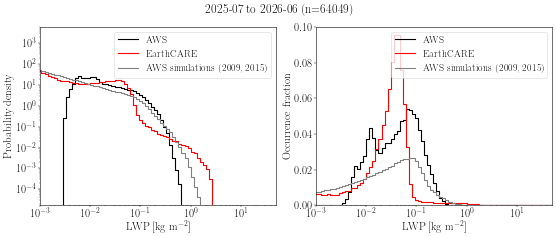

In [5]:
aws_hist_density = total_aws_counts / (total_aws_n * bin_widths)
ea_hist_density = total_ea_counts / (total_ea_n * bin_widths)

# occurrence fractions: counts / total, so each sums to 1 over all bins
aws_occ_frac = total_aws_counts / total_aws_n
ea_occ_frac = total_ea_counts / total_ea_n


fig, (ax_pdf, ax_of) = plt.subplots(1, 2, figsize=(14, 6))

# probability density
ax_pdf.step(bin_centres, aws_hist_density, where="mid", lw=2,
            color="black", label="AWS")
ax_pdf.step(bin_centres, ea_hist_density, where="mid", lw=2,
            color="red", label="EarthCARE")
ax_pdf.step(bin_centres, database_pdf, where="mid", lw=2,
            color="grey", label="AWS simulations (2009, 2015)")
ax_pdf.set_yscale("log")
ax_pdf.set_ylabel("Probability density")
#ax_pdf.set_ylim([1e-4, 5e2])

# occurrence fraction
ax_of.step(bin_centres, aws_occ_frac, where="mid", lw=2,
           color="black", label="AWS")
ax_of.step(bin_centres, ea_occ_frac, where="mid", lw=2,
           color="red", label="EarthCARE")
ax_of.step(bin_centres, database_occ_frac, where="mid", lw=2,
           color="grey", label="AWS simulations (2009, 2015)")
ax_of.set_ylabel("Occurrence fraction")
ax_of.set_ylim([0, 0.1])

for ax in (ax_pdf, ax_of):
    ax.set_xscale("log")
    ax.set_xlim(1e-3, 5e1)
    ax.set_xlabel(rf"{variable_label} [kg m$^{{-2}}$]")
    ax.legend()

period_label = date_str.replace("_to_", " to ").replace("_", ", ")
fig.suptitle(f"{period_label} (n={total_aws_n})", fontsize = 22)

fig.tight_layout()
plt.savefig(f"../figures/collocation_statistics/aws_earthcare_{quantity}_distributions_{date_str}.png",
            facecolor="white", bbox_inches="tight", dpi=200)

True


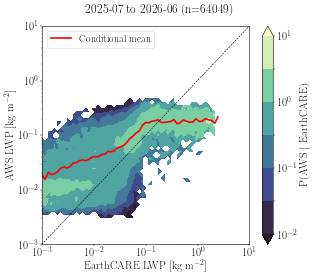

In [6]:

# ------------------------------------------------------------
# data: joint_counts rows = EarthCARE (x), columns = AWS (y)
# ------------------------------------------------------------
counts = h["joint_counts"]
bins = h["bins"]
bin_centres = np.sqrt(bins[:-1] * bins[1:])
n_pairs = counts.sum()
min_count = 10

p_aws_given_ea, counts_ea, conditional_mean_aws_given_ea = plot_utils.conditional_probability_from_counts(
    counts, bins, bins, bin_centres, log=True
)

# blank empty cells and EarthCARE bins with too few pairs
p_plot = np.where(p_aws_given_ea > 0, p_aws_given_ea, np.nan)
p_plot[:, counts_ea < min_count] = np.nan

# mean and median AWS FWP in each EarthCARE bin
joint = counts.T   # rows = AWS, columns = EarthCARE
with np.errstate(invalid="ignore", divide="ignore"):
    mean_aws = (joint * bin_centres[:, None]).sum(axis=0) / counts_ea
mean_aws[counts_ea < min_count] = np.nan

cum = np.cumsum(joint, axis=0)
median_aws = np.full(joint.shape[1], np.nan)
for j in range(joint.shape[1]):
    if counts_ea[j] >= min_count:
        median_aws[j] = bin_centres[np.searchsorted(cum[:, j], counts_ea[j] / 2)]

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
levels = np.logspace(-2, 1, 7)

fig, ax = plt.subplots(figsize=(8, 7))
cf = ax.contourf(bin_centres, bin_centres, p_plot,
                 levels=levels, norm=LogNorm(), cmap=cmc.cm.deep_r, extend="both")
fig.colorbar(cf, ax=ax, label="P(AWS $|$ EarthCARE)")


ax.plot(bin_centres, conditional_mean_aws_given_ea, color="red", lw=3, label="Conditional mean")
#ax.plot(bin_centres, median_aws, color="magenta", lw=2, label="Median AWS")
ax.plot([1e-3, 1e2], [1e-3, 1e2], color="black", ls="--", lw=1)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-3, 1e1)
ax.set_ylim(1e-3, 1e1)
ax.set_xlabel(rf"EarthCARE {variable_label} [kg m$^{{-2}}$]")
ax.set_ylabel(rf"AWS {variable_label} [kg m$^{{-2}}$]")

period_label = date_str.replace("_to_", " to ").replace("_", ", ")
fig.suptitle(f"{period_label} (n={total_aws_n})", fontsize=22)

ax.legend(loc="upper left")
fig.tight_layout()
plt.savefig(f"../figures/collocation_statistics/aws_earthcare_{quantity}_conditional_{date_str}.png",
            facecolor="white", bbox_inches="tight", dpi=200)

True


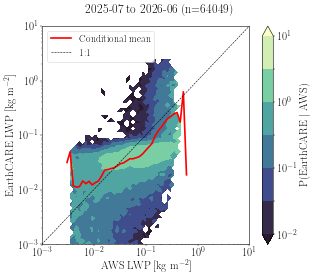

In [7]:
# ------------------------------------------------------------
# data: rows = AWS (x), columns = EarthCARE (y)
# ------------------------------------------------------------
counts_aws_x = h["joint_counts"].T
bins = h["bins"]
bin_centres = np.sqrt(bins[:-1] * bins[1:])
n_pairs = counts_aws_x.sum()
min_count = 10

p_ea_given_aws, counts_aws, conditional_mean_ea_given_aws = plot_utils.conditional_probability_from_counts(
    counts_aws_x, bins, bins, bin_centres, log=True
)

# blank empty cells and AWS bins with too few pairs
p_plot = np.where(p_ea_given_aws > 0, p_ea_given_aws, np.nan)
p_plot[:, counts_aws < min_count] = np.nan

# mean and median EarthCARE IWP in each AWS bin
joint = h["joint_counts"]   # rows = EarthCARE, columns = AWS
with np.errstate(invalid="ignore", divide="ignore"):
    mean_ea = (joint * bin_centres[:, None]).sum(axis=0) / counts_aws
mean_ea[counts_aws < min_count] = np.nan

cum = np.cumsum(joint, axis=0)
median_ea = np.full(joint.shape[1], np.nan)
for j in range(joint.shape[1]):
    if counts_aws[j] >= min_count:
        median_ea[j] = bin_centres[np.searchsorted(cum[:, j], counts_aws[j] / 2)]

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
levels = np.logspace(-2, 1, 7)

fig, ax = plt.subplots(figsize=(8, 7))
cf = ax.contourf(bin_centres, bin_centres, p_plot,
                 levels=levels, norm=LogNorm(), cmap=cmc.cm.deep_r, extend="both")
fig.colorbar(cf, ax=ax, label="P(EarthCARE $|$ AWS)")

#ax.plot(bin_centres, mean_ea, color="red", lw=2, label="Mean EarthCARE")
ax.plot(bin_centres, conditional_mean_ea_given_aws, color="red", lw=3, label="Conditional mean")
#ax.plot(bin_centres, median_ea, color="magenta", lw=2, label="Median EarthCARE")
ax.plot([1e-3, 1e2], [1e-3, 1e2], color="black", ls="--", lw=1, label="1:1")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-3, 1e1)
ax.set_ylim(1e-3, 1e1)
ax.set_xlabel(rf"AWS {variable_label} [kg m$^{{-2}}$]")
ax.set_ylabel(rf"EarthCARE {variable_label} [kg m$^{{-2}}$]")

period_label = date_str.replace("_to_", " to ").replace("_", ", ")
fig.suptitle(f"{period_label} (n={total_aws_n})", fontsize=22)

ax.legend(loc="upper left")
fig.tight_layout()
plt.savefig(f"../figures/collocation_statistics/aws_earthcare_{quantity}_conditional_on_aws_{date_str}.png",
            facecolor="white", bbox_inches="tight", dpi=200)

In [8]:
# ------------------------------------------------------------
# Zm: statistics from compute_aws_earthcare_zm_stats.py
# ------------------------------------------------------------
with open(f"../data/aws_earthcare_zm_histograms_{date_str}.pkl", "rb") as f:
    h_zm = pickle.load(f)["zm"]

zm_label = r"$Z_{\mathrm{m}}$"
min_wp = h_zm["config"]["min_wp"]   # FWP/IWP cut used for the collocations

# bins in km for plotting
zm_bins_km = h_zm["bins"] / 1000
zm_bin_widths_km = np.diff(zm_bins_km)
zm_bin_centres_km = 0.5 * (zm_bins_km[:-1] + zm_bins_km[1:])

zm_aws_counts = h_zm["aws_counts"]
zm_ea_counts = h_zm["ea_counts"]
zm_aws_n = h_zm["aws_n"]
zm_ea_n = h_zm["ea_n"]

# database Zm, same months and same minimum FWP as the collocations
DB_ZM_VAR = "Zm"   # name of Zm in the training database, in m
if DB_ZM_VAR in ds_training:
    db_fwp = ds_training["Fwp"].values
    db_keep = keep & (db_fwp >= min_wp)
    db_zm_km = ds_training[DB_ZM_VAR].values[db_keep] / 1000
    db_zm_km = db_zm_km[np.isfinite(db_zm_km)]
    zm_database_counts, _ = np.histogram(db_zm_km, bins=zm_bins_km)
    print(f"{db_zm_km.size} database cases with FWP >= {min_wp} in months {months}")
else:
    zm_database_counts = None
    print(f"no variable {DB_ZM_VAR} in the training database, leaving it out of the Zm plots")

no variable Zm in the training database, leaving it out of the Zm plots


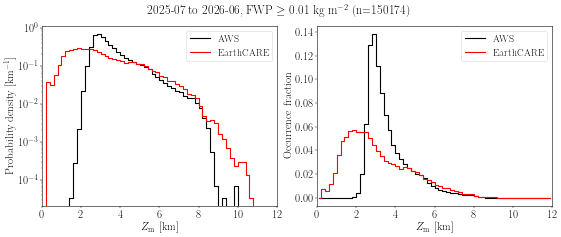

In [9]:
# densities per km, and occurrence fractions that sum to 1 over all bins
zm_aws_density = zm_aws_counts / (zm_aws_n * zm_bin_widths_km)
zm_ea_density = zm_ea_counts / (zm_ea_n * zm_bin_widths_km)
zm_aws_occ_frac = zm_aws_counts / zm_aws_n
zm_ea_occ_frac = zm_ea_counts / zm_ea_n


fig, (ax_pdf, ax_of) = plt.subplots(1, 2, figsize=(14, 6))

# probability density
ax_pdf.step(zm_bin_centres_km, zm_aws_density, where="mid", lw=2,
            color="black", label="AWS")
ax_pdf.step(zm_bin_centres_km, zm_ea_density, where="mid", lw=2,
            color="red", label="EarthCARE")
ax_pdf.set_yscale("log")
ax_pdf.set_ylabel(r"Probability density [km$^{-1}$]")

# occurrence fraction
ax_of.step(zm_bin_centres_km, zm_aws_occ_frac, where="mid", lw=2,
           color="black", label="AWS")
ax_of.step(zm_bin_centres_km, zm_ea_occ_frac, where="mid", lw=2,
           color="red", label="EarthCARE")
ax_of.set_ylabel("Occurrence fraction")

if zm_database_counts is not None:
    db_n = zm_database_counts.sum()
    ax_pdf.step(zm_bin_centres_km, zm_database_counts / (db_n * zm_bin_widths_km),
                where="mid", lw=2, color="grey", label="AWS simulations (2009, 2015)")
    ax_of.step(zm_bin_centres_km, zm_database_counts / db_n,
               where="mid", lw=2, color="grey", label="AWS simulations (2009, 2015)")

for ax in (ax_pdf, ax_of):
    ax.set_xlim(zm_bins_km[0], zm_bins_km[-1])
    ax.set_xlabel(f"{zm_label} [km]")
    ax.legend()

period_label = date_str.replace("_to_", " to ").replace("_", ", ")
fig.suptitle(f"{period_label}, FWP $\\geq$ {min_wp} kg m$^{{-2}}$ (n={zm_aws_n})", fontsize=22)

fig.tight_layout()
plt.savefig(f"../figures/collocation_statistics/aws_earthcare_zm_distributions_{date_str}.png",
            facecolor="white", bbox_inches="tight", dpi=200)

True


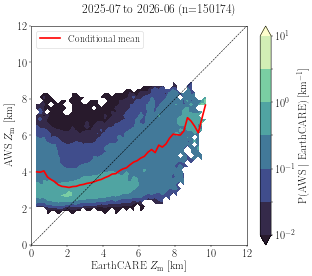

In [10]:
# ------------------------------------------------------------
# Zm, data: joint_counts rows = EarthCARE (x), columns = AWS (y)
# ------------------------------------------------------------
counts = h_zm["joint_counts"]
min_count = 10

p_aws_given_ea, counts_ea, conditional_mean_aws_given_ea = plot_utils.conditional_probability_from_counts(
    counts, zm_bins_km, zm_bins_km, zm_bin_centres_km, log=False
)

# blank empty cells and EarthCARE bins with too few pairs
p_plot = np.where(p_aws_given_ea > 0, p_aws_given_ea, np.nan)
p_plot[:, counts_ea < min_count] = np.nan
conditional_mean_aws_given_ea = np.where(counts_ea >= min_count, conditional_mean_aws_given_ea, np.nan)

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
levels = np.logspace(-2, 1, 7)

fig, ax = plt.subplots(figsize=(8, 7))
cf = ax.contourf(zm_bin_centres_km, zm_bin_centres_km, p_plot,
                 levels=levels, norm=LogNorm(), cmap=cmc.cm.deep_r, extend="both")
fig.colorbar(cf, ax=ax, label=r"P(AWS $|$ EarthCARE) [km$^{-1}$]")

ax.plot(zm_bin_centres_km, conditional_mean_aws_given_ea, color="red", lw=3, label="Conditional mean")
ax.plot([0, zm_bins_km[-1]], [0, zm_bins_km[-1]], color="black", ls="--", lw=1)

ax.set_xlim(zm_bins_km[0], zm_bins_km[-1])
ax.set_ylim(zm_bins_km[0], zm_bins_km[-1])
ax.set_xlabel(f"EarthCARE {zm_label} [km]")
ax.set_ylabel(f"AWS {zm_label} [km]")

period_label = date_str.replace("_to_", " to ").replace("_", ", ")
fig.suptitle(f"{period_label} (n={zm_aws_n})", fontsize=22)

ax.legend(loc="upper left")
fig.tight_layout()
plt.savefig(f"../figures/collocation_statistics/aws_earthcare_zm_conditional_{date_str}.png",
            facecolor="white", bbox_inches="tight", dpi=200)

True


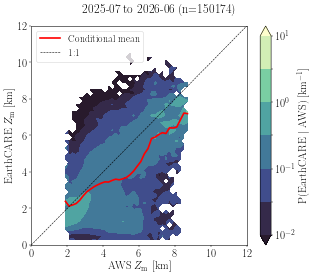

In [11]:
# ------------------------------------------------------------
# Zm, data: rows = AWS (x), columns = EarthCARE (y)
# ------------------------------------------------------------
counts_aws_x = h_zm["joint_counts"].T
min_count = 10

p_ea_given_aws, counts_aws, conditional_mean_ea_given_aws = plot_utils.conditional_probability_from_counts(
    counts_aws_x, zm_bins_km, zm_bins_km, zm_bin_centres_km, log=False
)

# blank empty cells and AWS bins with too few pairs
p_plot = np.where(p_ea_given_aws > 0, p_ea_given_aws, np.nan)
p_plot[:, counts_aws < min_count] = np.nan
conditional_mean_ea_given_aws = np.where(counts_aws >= min_count, conditional_mean_ea_given_aws, np.nan)

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
levels = np.logspace(-2, 1, 7)

fig, ax = plt.subplots(figsize=(8, 7))
cf = ax.contourf(zm_bin_centres_km, zm_bin_centres_km, p_plot,
                 levels=levels, norm=LogNorm(), cmap=cmc.cm.deep_r, extend="both")
fig.colorbar(cf, ax=ax, label=r"P(EarthCARE $|$ AWS) [km$^{-1}$]")

ax.plot(zm_bin_centres_km, conditional_mean_ea_given_aws, color="red", lw=3, label="Conditional mean")
ax.plot([0, zm_bins_km[-1]], [0, zm_bins_km[-1]], color="black", ls="--", lw=1, label="1:1")

ax.set_xlim(zm_bins_km[0], zm_bins_km[-1])
ax.set_ylim(zm_bins_km[0], zm_bins_km[-1])
ax.set_xlabel(f"AWS {zm_label} [km]")
ax.set_ylabel(f"EarthCARE {zm_label} [km]")

period_label = date_str.replace("_to_", " to ").replace("_", ", ")
fig.suptitle(f"{period_label} (n={zm_aws_n})", fontsize=22)

ax.legend(loc="upper left")
fig.tight_layout()
plt.savefig(f"../figures/collocation_statistics/aws_earthcare_zm_conditional_on_aws_{date_str}.png",
            facecolor="white", bbox_inches="tight", dpi=200)